In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlacca_functions as mlcf
from sklearn.utils.class_weight import compute_class_weight

In [2]:
data_folder = 'data\\csv_files\\molec_db'

save_csvs_folder = 'data\\csv_files'
save_plots_folder = 'data\\plots'

In [3]:
LM_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and 'l&m' in x]

In [4]:
# Functions
def get_elements_from_formula(formula) -> dict:
    elements = {}
    current_element = ''
    current_count = ''
    for char in formula:
        if char.isupper():
            if current_element:
                elements[current_element] = int(current_count) if current_count else 1
            current_element = char
            current_count = ''
        elif char.islower():
            current_element += char
        elif char.isdigit():
            current_count += char
    if current_element:
        elements[current_element] = int(current_count) if current_count else 1
    return elements


def get_peptide_formula(sequence, amino_acids_dict) -> dict:
    total_elements = {}
    for aa in sequence:
        aa_elements = amino_acids_dict.get(aa, {})
        for element, count in aa_elements.items():
            total_elements[element] = total_elements.get(element, 0) + count
    return total_elements

In [5]:
overall_df = pd.DataFrame()
amino_acids_dict = {}

for file in LM_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)

    # Further processing and analysis of df

    category = file.replace('.csv', '').replace('l&m-', '')

    # save the results with the category name

    if category == 'amino_acid':
        for letter in df['1-letter code']:
            amino_acids_dict[letter] = get_elements_from_formula(df['FORMULA'][df['1-letter code'] == letter].to_list()[0])
        
        category = 'peptide'
    
    df_slice = pd.DataFrame({'category':[category] * len(df)})
    atomic_dict = {'C':[], 'H':[], 'O':[], 'N':[], 'S':[], 'P':[]}

    try:
        df_slice['formula'] = df['FORMULA']

    except KeyError:
        if category == 'peptide':
            seqs = df['Sequence'].to_list()
            formula_dict_list = [get_peptide_formula(seq, amino_acids_dict) for seq in seqs]
            df_slice['formula'] = [''.join([f'{x}{formula_dict[x]}' for x in formula_dict]) for formula_dict in formula_dict_list]

        elif category == 'lignin':
            for element in atomic_dict.keys():
                if element in df.columns:
                    atomic_dict[element] = df[element].to_list()
                else:
                    atomic_dict[element] = [0] * len(df)
    
    if category != 'lignin':
        for formula in df_slice['formula']:
            elements = get_elements_from_formula(formula)
            for element in atomic_dict.keys():
                atomic_dict[element].append(elements.get(element, 0))
    
    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)
    
    if len(overall_df) == 0:
        overall_df = df_slice
    else:
        overall_df = pd.concat([overall_df, df_slice], ignore_index=True)

# calculate elemental ratios
for element in atomic_dict.keys():
    if element != 'C':
        overall_df[f'{element}/C'] = overall_df[element] / overall_df['C']

In [6]:
# print the count for each category
print(overall_df['category'].value_counts())

# sort the dataframe by category
overall_df = overall_df.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [7]:
# since the dataset is not balanced as there are more samples in some categories, we can compute class weights

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df['category']), y=overall_df['category'])
weights_dict = {cls: weight for cls, weight in zip(np.unique(overall_df['category']), class_weights)}

overall_df['weights'] = [weights_dict[cat] for cat in overall_df['category']]

In [8]:
overall_df.to_csv(f'{save_csvs_folder}\\new_vk_areas_df.csv', index=False)

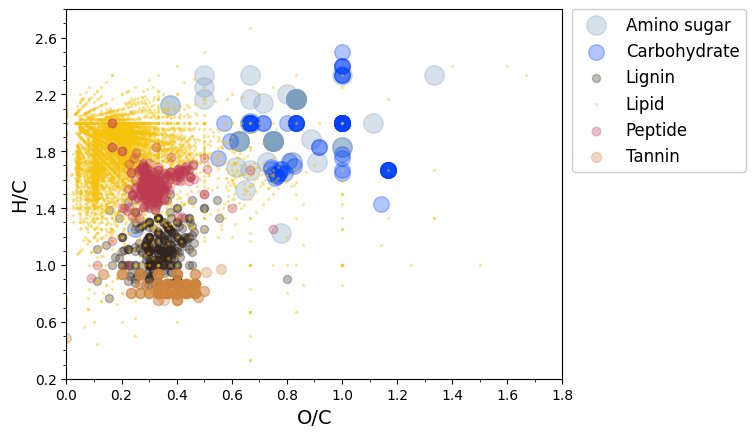

In [9]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in overall_df['category'].unique():
    subset = overall_df[overall_df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], label=category.capitalize().replace('_',' ') if category != 'pah' else 'PAH',
               c = mlcf.vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df[overall_df['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)
ax.set_xlim(0,1.8)
ax.set_ylim(0,3)

mlcf.set_axis_ticks(overall_df['O/C'].values,ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(overall_df['H/C'].values,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig(f'{save_plots_folder}\\vk_diagram.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')


# Create a CSV file to include PAHs as well 

In [10]:
all_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and x not in LM_files]

In [11]:
overall_df_with_pahs = pd.DataFrame()

for file in all_files:
    df = pd.read_csv(os.path.join(data_folder, file))

    category = file.replace('.csv', '')

    atomic_dict = {'C':[], 'H':[], 'O':[], 'N':[], 'S':[], 'P':[]}

    df_slice = pd.DataFrame({'category':[category] * len(df)})
    df_slice['formula'] = df['FORMULA']

    for formula in df_slice['formula']:
        elements = get_elements_from_formula(formula)

        for element in atomic_dict.keys():
            atomic_dict[element].append(elements.get(element, 0))

    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)

    for element in atomic_dict.keys():
        if element != 'C':
            df_slice[f'{element}/C'] = df_slice[element] / df_slice['C']
    
    overall_df_with_pahs = pd.concat([overall_df, df_slice], ignore_index=True) if len(overall_df_with_pahs) == 0 else pd.concat([overall_df_with_pahs, df_slice], ignore_index=True)

# print the count for each category
print(overall_df_with_pahs['category'].value_counts())

# sort the dataframe by category
overall_df_with_pahs = overall_df_with_pahs.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
pah               86
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [12]:
# since the dataset is not balanced as there are more samples in some categories, we can compute class weights

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df_with_pahs['category']), y=overall_df_with_pahs['category'])
weights_dict_with_pahs = {cls: weight for cls, weight in zip(np.unique(overall_df_with_pahs['category']), class_weights)}

overall_df_with_pahs['weights'] = [weights_dict_with_pahs[cat] for cat in overall_df_with_pahs['category']]

overall_df_with_pahs.to_csv(f'{save_csvs_folder}\\new_vk_areas_with_pahs.csv', index=False)

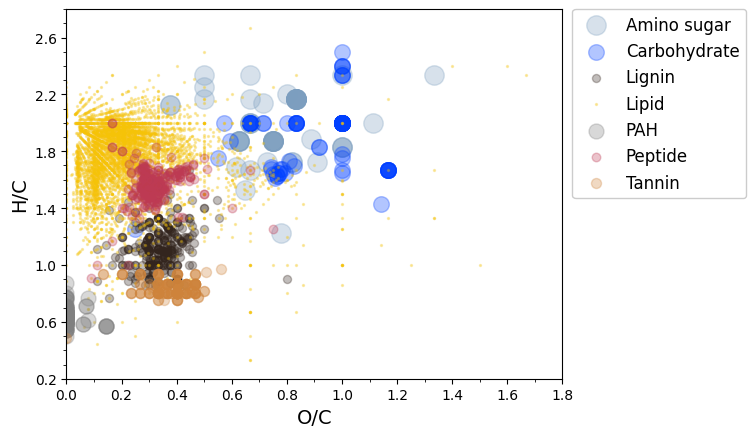

In [13]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in overall_df_with_pahs['category'].unique():
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'], label=category.capitalize().replace('_',' ') if category != 'pah' else 'PAH',
               c=mlcf.vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df_with_pahs[overall_df_with_pahs['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'].values,ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'].values,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')